# 03 — Łączenie zbiorów + EDA

Połączenie generacji OZE z PSE (notebook 01) z pogodą z Open-Meteo Archive (notebook 02), dodanie cech czasowych, eksploracyjna analiza danych. Wynik: `data/processed/dataset_full.csv`.

Pełny opis projektu w README.

## 3.1 Wczytanie zbiorów

Trzy źródła:

- **`pse_oze_2023_2025.csv`** — generacja (target), 3 lata
- **`pogoda_2023_2024_era5.csv`** — pogoda z reanalizy ERA5 (idealna), 2 lata na trening i walidację
- **`pogoda_2025_prognozy.csv`** — prognozy historyczne (z błędem), 1 rok na test

Pogodę z dwóch źródeł sklejamy w jeden zbiór 2023-2025. W zbiorze dorzucamy kolumnę `is_test` oznaczającą wiersze pochodzące z prognoz — przyda się przy podziale train/val/test w bloku 4.

In [19]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("data/processed")

pse = pd.read_csv(OUTPUT_DIR / "pse_oze_2023_2025.csv", sep=";", decimal=",", parse_dates=["timestamp"]).set_index("timestamp")
era5 = pd.read_csv(OUTPUT_DIR / "pogoda_2023_2024_era5.csv", sep=";", decimal=",", parse_dates=["timestamp"]).set_index("timestamp")
forecast = pd.read_csv(OUTPUT_DIR / "pogoda_2025_prognozy.csv", sep=";", decimal=",", parse_dates=["timestamp"]).set_index("timestamp")

print(f"PSE:        {pse.shape}, zakres: {pse.index.min()} -> {pse.index.max()}")
print(f"ERA5:       {era5.shape}, zakres: {era5.index.min()} -> {era5.index.max()}")
print(f"Prognozy:   {forecast.shape}, zakres: {forecast.index.min()} -> {forecast.index.max()}")

PSE:        (26304, 2), zakres: 2023-01-01 00:00:00 -> 2025-12-31 23:00:00
ERA5:       (17544, 40), zakres: 2023-01-01 00:00:00 -> 2024-12-31 23:00:00
Prognozy:   (8760, 40), zakres: 2025-01-01 00:00:00 -> 2025-12-31 23:00:00


Trzy zbiory z poprzednich notebooków. ERA5 i prognozy mają identyczny format (40 kolumn, te same nazwy), różnią się tylko źródłem.

## 3.2 Sklejenie pogody i połączenie z generacją

In [20]:
pogoda = pd.concat([era5, forecast], axis=0).sort_index()
pogoda["is_test"] = (pogoda.index.year == 2025).astype(int)

df = pd.concat([pogoda, pse], axis=1)

print(f"sklejony zbiór: {df.shape}")
print(f"NaN-y: {df.isna().sum().sum()}")
print(f"is_test=0 (train+val): {(df['is_test']==0).sum()} wierszy")
print(f"is_test=1 (test):       {(df['is_test']==1).sum()} wierszy")
df.head()

sklejony zbiór: (26304, 43)
NaN-y: 0
is_test=0 (train+val): 17544 wierszy
is_test=1 (test):       8760 wierszy


,wind100_szczecin,wind10_szczecin,rad_szczecin,rad_dir_szczecin,cloud_szczecin,temp_szczecin,wind100_slupsk,wind10_slupsk,rad_slupsk,rad_dir_slupsk,...,wdir100_cos_slupsk,wdir100_sin_bydgoszcz,wdir100_cos_bydgoszcz,wdir100_sin_warszawa,wdir100_cos_warszawa,wdir100_sin_krakow,wdir100_cos_krakow,is_test,wi,pv
timestamp,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,13.23,8.13,0.0,0.0,100,14.9,12.66,7.56,0.0,0.0,...,-0.453990,-0.838671,-0.544639,-0.809017,-0.587785,-0.891007,-0.453990,0,5529.188,0.0
2023-01-01 01:00:00,13.09,7.92,0.0,0.0,100,14.3,13.82,8.51,0.0,0.0,...,-0.615661,-0.857167,-0.515038,-0.809017,-0.587785,-0.809017,-0.587785,0,4250.700,0.0
2023-01-01 02:00:00,12.63,7.43,0.0,0.0,100,13.9,10.98,6.31,0.0,0.0,...,-0.615661,-0.848048,-0.529919,-0.882948,-0.469472,-0.707107,-0.707107,0,3124.613,0.0
2023-01-01 03:00:00,13.27,7.99,0.0,0.0,100,14.6,14.53,8.94,0.0,0.0,...,-0.559193,-0.819152,-0.573576,-0.838671,-0.544639,-0.707107,-0.707107,0,3486.663,0.0
2023-01-01 04:00:00,13.67,8.44,0.0,0.0,100,15.3,14.40,8.88,0.0,0.0,...,-0.559193,-0.891007,-0.453990,-0.809017,-0.587785,-0.743145,-0.669131,0,4257.800,0.0


ERA5 (2023-2024) i prognozy (2025) sklejone w jeden ciąg czasowy, dorzucona kolumna `is_test` jako flaga zbioru testowego. Następnie połączone z generacją z PSE po timestampie.

## 3.3 Cechy czasowe

Godzina i dzień roku to zmienne cykliczne — godzina 23 i 0 są blisko siebie, podobnie 31 grudnia i 1 stycznia. Sieć neuronowa traktująca to liniowo nie zauważy tego cyklu, dlatego konwertujemy na sinus i cosinus.

In [21]:
hour = df.index.hour
doy = df.index.dayofyear

df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)
df["doy_sin"]  = np.sin(2 * np.pi * doy / 365.25)
df["doy_cos"]  = np.cos(2 * np.pi * doy / 365.25)

print(f"kolumn po dodaniu cech czasowych: {df.shape[1]}")
df[["hour_sin", "hour_cos", "doy_sin", "doy_cos"]].head()

kolumn po dodaniu cech czasowych: 47


,hour_sin,hour_cos,doy_sin,doy_cos
timestamp,,,,
2023-01-01 00:00:00,0.000000,1.000000,0.017202,0.999852
2023-01-01 01:00:00,0.258819,0.965926,0.017202,0.999852
2023-01-01 02:00:00,0.500000,0.866025,0.017202,0.999852
2023-01-01 03:00:00,0.707107,0.707107,0.017202,0.999852
2023-01-01 04:00:00,0.866025,0.500000,0.017202,0.999852


Z 43 kolumn (40 pogoda + `is_test` + 2 targety) zrobiło się 47 (dorzuciliśmy 4 cechy czasowe).

## 3.4 Rozkłady targetów

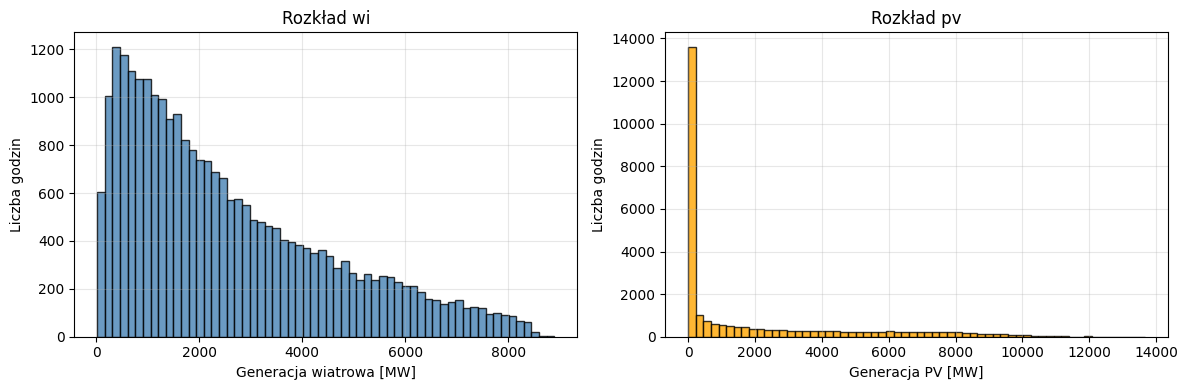

            wi       pv
count  26304.0  26304.0
mean    2578.1   1893.1
std     2005.4   2816.9
min       19.5      0.0
25%      960.4      0.0
50%     2032.1    146.4
75%     3800.1   3107.5
max     8894.6  13665.3


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["wi"], bins=60, color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Generacja wiatrowa [MW]")
axes[0].set_ylabel("Liczba godzin")
axes[0].set_title("Rozkład wi")
axes[0].grid(alpha=0.3)

axes[1].hist(df["pv"], bins=60, color="orange", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Generacja PV [MW]")
axes[1].set_ylabel("Liczba godzin")
axes[1].set_title("Rozkład pv")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(df[["wi", "pv"]].describe().round(1))

`wi` ma rozkład skośny (długi ogon w prawo — rzadkie godziny silnego wiatru), `pv` ma duży pik przy zerze (noce, ~50% godzin) i rozkład zbliżony do wykładniczego dla godzin dziennych.

## 3.5 Sezonowość

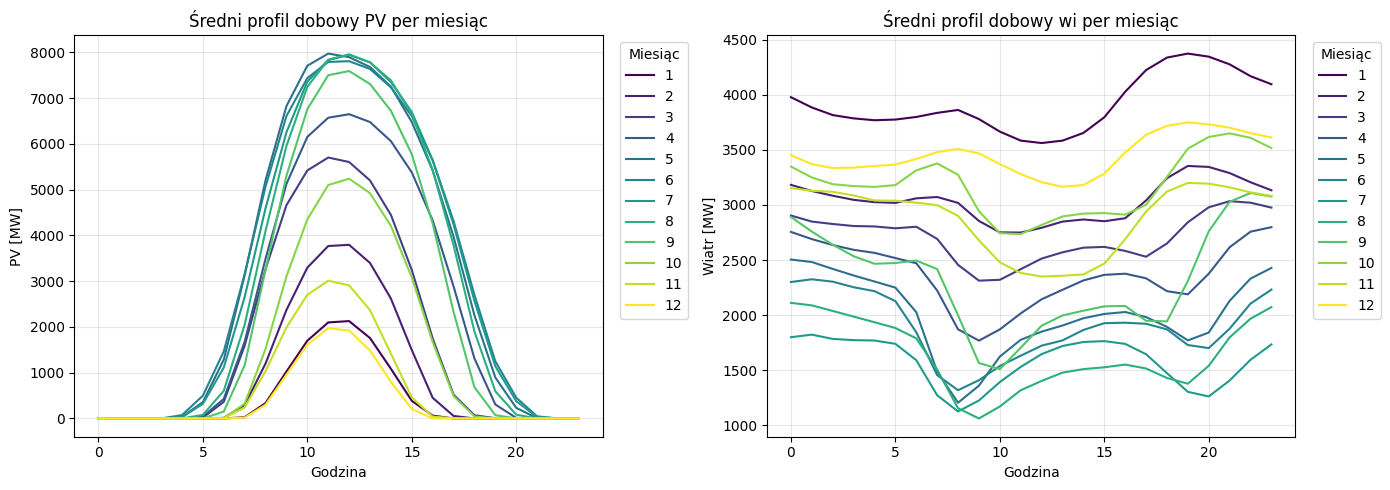

In [23]:
df_temp = df[["wi", "pv"]].copy()
df_temp["month"] = df_temp.index.month
df_temp["hour"] = df_temp.index.hour

profile_pv = df_temp.groupby(["month", "hour"])["pv"].mean().unstack(level=0)
profile_wi = df_temp.groupby(["month", "hour"])["wi"].mean().unstack(level=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
profile_pv.plot(ax=axes[0], colormap="viridis", lw=1.5)
axes[0].set_title("Średni profil dobowy PV per miesiąc")
axes[0].set_xlabel("Godzina")
axes[0].set_ylabel("PV [MW]")
axes[0].legend(title="Miesiąc", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[0].grid(alpha=0.3)

profile_wi.plot(ax=axes[1], colormap="viridis", lw=1.5)
axes[1].set_title("Średni profil dobowy wi per miesiąc")
axes[1].set_xlabel("Godzina")
axes[1].set_ylabel("Wiatr [MW]")
axes[1].legend(title="Miesiąc", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

PV: wyraźny cykl dobowy z szczytem w południe, latem szerszy łuk i wyższe wartości — silna sezonowość zarówno dobowa jak i roczna. Wiatr: cykl dobowy płaski (wiatr nie zna pory dnia), za to widoczna jest silna sezonowość roczna — zimą generacja niemal dwukrotnie wyższa niż latem, ze względu na bardziej dynamiczną atmosferę (silne wyże i niże).

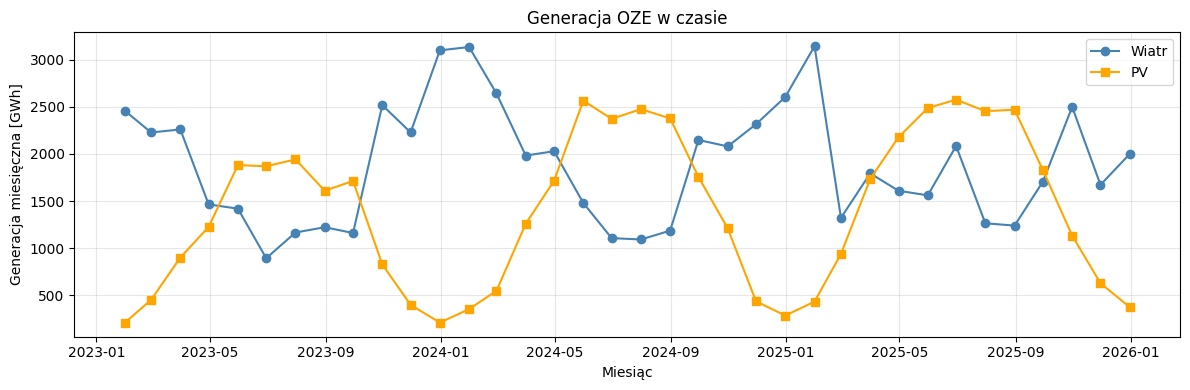

In [24]:
monthly = df[["wi", "pv"]].resample("ME").sum() / 1000

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.index, monthly["wi"], color="steelblue", marker="o", label="Wiatr")
ax.plot(monthly.index, monthly["pv"], color="orange", marker="s", label="PV")
ax.set_xlabel("Miesiąc")
ax.set_ylabel("Generacja miesięczna [GWh]")
ax.set_title("Generacja OZE w czasie")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Wiatr ma sezonowość roczną odwrotną do PV — najwięcej w zimie (silne wyże/niże), najmniej w lecie. PV odwrotnie. Trend wzrostowy PV pokazuje rosnącą moc zainstalowaną w tych latach.

## 3.6 Korelacje pogoda → generacja

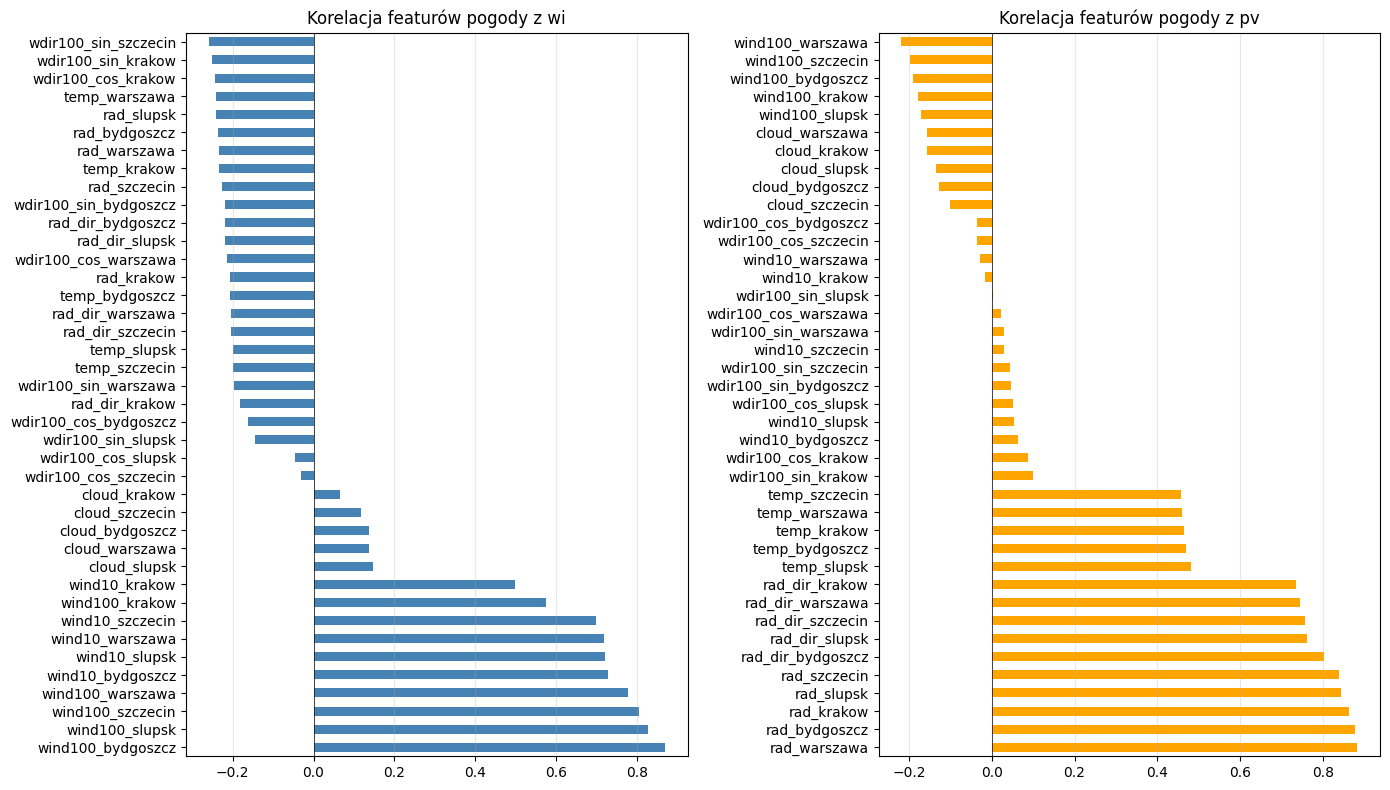

In [25]:
weather_cols = [c for c in df.columns if c not in ["wi", "pv", "hour_sin", "hour_cos", "doy_sin", "doy_cos", "is_test"]]
corr_wi = df[weather_cols].corrwith(df["wi"]).sort_values(ascending=False)
corr_pv = df[weather_cols].corrwith(df["pv"]).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))
corr_wi.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Korelacja featurów pogody z wi")
axes[0].axvline(0, color="black", lw=0.5)
axes[0].grid(alpha=0.3, axis="x")

corr_pv.plot(kind="barh", ax=axes[1], color="orange")
axes[1].set_title("Korelacja featurów pogody z pv")
axes[1].axvline(0, color="black", lw=0.5)
axes[1].grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

Najmocniejsze korelacje są zgodne z fizyką:
- `wind100_*` z `wi` — korelacje ~0.8 (prędkość wiatru na wysokości turbiny to bezpośredni predyktor generacji wiatrowej)
- `rad_*` z `pv` — korelacje ~0.85-0.9 (promieniowanie słoneczne to bezpośredni predyktor PV)

`cloud_cover` ma stosunkowo słabą korelację z `pv` (~-0.2), choć intuicja mówi inaczej. Wynika to z dwóch rzeczy: po pierwsze, `shortwave_radiation` już zawiera informację o zachmurzeniu (chmury redukują radiację), więc dwa featury mierzą ten sam efekt. Po drugie, nocą `cloud_cover` może być wysokie ale `pv = 0` niezależnie od chmur, co rozcieńcza korelację globalną. Sieć neuronowa sama ustali odpowiednie wagi, ewentualne redundancje są dla niej naturalne.

Korelacje ujemne wzajemne między featurami (np. `wind100_*` ujemne z `pv`) wynikają z sezonowości — zimą wiatr jest silniejszy, a radiacja niższa.

## 3.7 Outliery i wartości skrajne

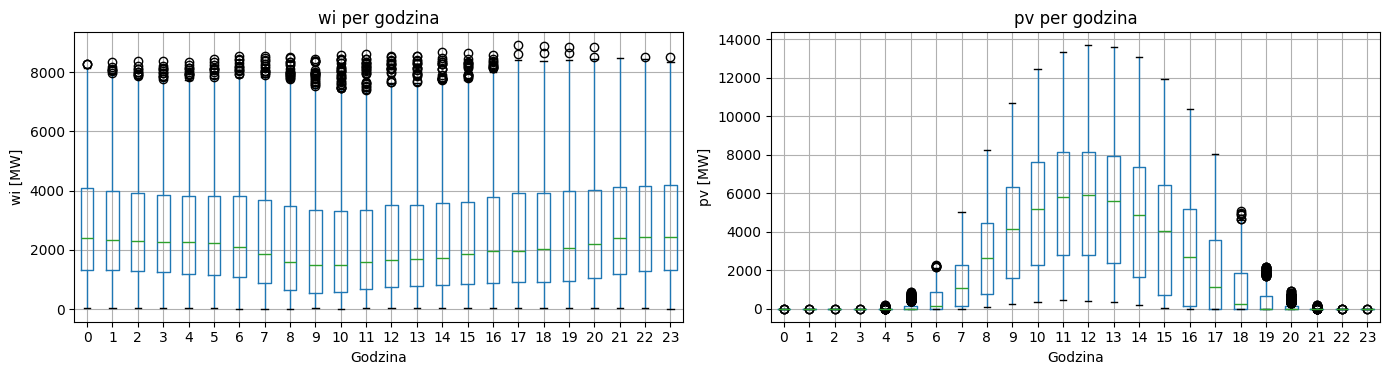

wi < 0: 0
pv < 0: 0
pv > 100 MW w nocy (godz. 23-3): 0


In [26]:
df_plot = df[["wi", "pv"]].copy()
df_plot["hour"] = df.index.hour

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_plot.boxplot(column="wi", by="hour", ax=axes[0], showfliers=True)
axes[0].set_title("wi per godzina")
axes[0].set_xlabel("Godzina")
axes[0].set_ylabel("wi [MW]")

df_plot.boxplot(column="pv", by="hour", ax=axes[1], showfliers=True)
axes[1].set_title("pv per godzina")
axes[1].set_xlabel("Godzina")
axes[1].set_ylabel("pv [MW]")

plt.suptitle("")
plt.tight_layout()
plt.show()

print(f"wi < 0: {(df['wi'] < 0).sum()}")
print(f"pv < 0: {(df['pv'] < 0).sum()}")
print(f"pv > 100 MW w nocy (godz. 23-3): {((df.index.hour.isin([23,0,1,2,3])) & (df['pv'] > 100)).sum()}")

Boxploty pokazują rozkład per godzinę. Outliery (kropki) to po prostu rzadkie godziny ekstremalnej generacji — fizycznie poprawne, nie usuwamy. Brak wartości ujemnych ani PV nocą — dane są czyste.

## 3.8 Kompletność

In [27]:
print(f"NaN-y w całym zbiorze: {df.isna().sum().sum()}")
expected = pd.date_range(df.index.min(), df.index.max(), freq="1h")
missing = expected.difference(df.index)
print(f"Brakujące godziny: {len(missing)}")
print(f"Wierszy: {len(df)}, kolumn: {df.shape[1]}")

NaN-y w całym zbiorze: 0
Brakujące godziny: 0
Wierszy: 26304, kolumn: 47


Zbiór jest kompletny — żadnych NaN, żadnych luk, 26 304 wiersze pokrywające 3 lata co godzinę.

## 3.9 Porównanie ERA5 vs prognozy

Train/val operują na danych ERA5, test na prognozach. Sprawdzamy czy rozkłady kluczowych zmiennych są spójne — duża rozbieżność oznaczałaby że prognozy mają silny bias systematyczny i model wytrenowany na ERA5 może działać gorzej w produkcji niż wskazują metryki walidacyjne.

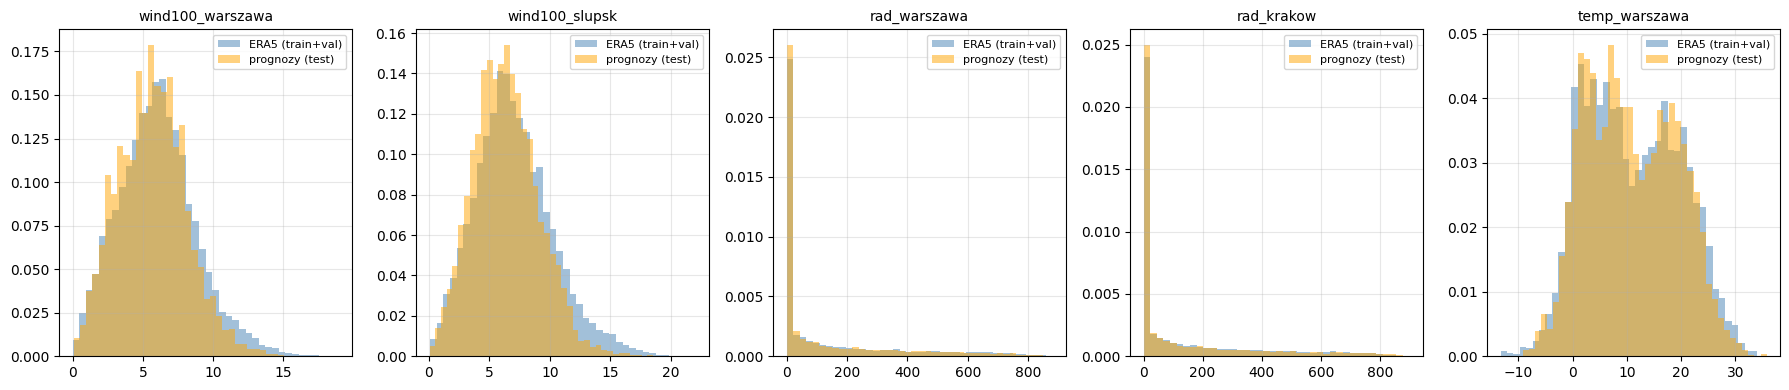

Statystyki — ERA5 vs prognozy
                         mean     std
wind100_warszawa_era5    6.05    2.75
wind100_slupsk_era5      7.07    3.20
rad_warszawa_era5      135.03  212.31
rad_krakow_era5        137.72  213.41
temp_warszawa_era5      11.03    8.70
wind100_warszawa_test    5.67    2.42
wind100_slupsk_test      6.38    2.68
rad_warszawa_test      126.09  204.62
rad_krakow_test        133.53  216.20
temp_warszawa_test      10.86    8.23


In [28]:
era5_part = df[df["is_test"] == 0]
test_part = df[df["is_test"] == 1]

key_features = ["wind100_warszawa", "wind100_slupsk", "rad_warszawa", "rad_krakow", "temp_warszawa"]

fig, axes = plt.subplots(1, len(key_features), figsize=(18, 4))
for ax, feat in zip(axes, key_features):
    ax.hist(era5_part[feat], bins=40, alpha=0.5, label="ERA5 (train+val)", color="steelblue", density=True)
    ax.hist(test_part[feat], bins=40, alpha=0.5, label="prognozy (test)", color="orange", density=True)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Statystyki — ERA5 vs prognozy")
comparison = pd.concat([
    era5_part[key_features].describe().loc[["mean", "std"]].add_suffix("_era5"),
    test_part[key_features].describe().loc[["mean", "std"]].add_suffix("_test"),
], axis=1).T.round(2)
print(comparison)

Rozkłady są bardzo zbliżone — średnie i odchylenia standardowe ERA5 i prognoz różnią się minimalnie. To dobrze — model wytrenowany na ERA5 powinien działać z prognozami bez większego biasu.

## 3.10 Zapis finalnego zbioru

In [29]:
output_file = OUTPUT_DIR / "dataset_full.csv"
df.to_csv(output_file, sep=";", decimal=",")
print(f"zapisano: {output_file}")
print(f"wierszy: {len(df)}, kolumn: {df.shape[1]}")
df.describe().round(2)

zapisano: data/processed/dataset_full.csv
wierszy: 26304, kolumn: 47


,wind100_szczecin,wind10_szczecin,rad_szczecin,rad_dir_szczecin,cloud_szczecin,temp_szczecin,wind100_slupsk,wind10_slupsk,rad_slupsk,rad_dir_slupsk,...,wdir100_cos_warszawa,wdir100_sin_krakow,wdir100_cos_krakow,is_test,wi,pv,hour_sin,hour_cos,doy_sin,doy_cos
count,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,...,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00,26304.00
mean,6.31,3.46,127.15,73.72,68.65,10.77,6.84,3.76,127.61,75.54,...,-0.11,-0.21,-0.01,0.33,2578.07,1893.15,-0.00,-0.00,0.00,0.00
std,2.72,1.76,200.27,146.98,39.59,7.63,3.06,2.01,202.87,150.27,...,0.65,0.82,0.53,0.47,2005.44,2816.92,0.71,0.71,0.71,0.71
min,0.10,0.00,0.00,0.00,0.00,-9.90,0.05,0.00,0.00,0.00,...,-1.00,-1.00,-1.00,0.00,19.50,0.00,-1.00,-1.00,-1.00,-1.00
25%,4.40,2.14,0.00,0.00,30.00,4.70,4.70,2.28,0.00,0.00,...,-0.74,-0.97,-0.36,0.00,960.43,0.00,-0.71,-0.71,-0.70,-0.71
50%,6.19,3.18,5.00,0.00,96.00,10.40,6.55,3.44,5.00,0.00,...,-0.16,-0.66,-0.03,0.00,2032.05,146.45,0.00,-0.00,-0.00,0.00
75%,8.00,4.47,185.00,64.00,100.00,16.70,8.67,4.90,183.00,65.00,...,0.45,0.80,0.34,1.00,3800.15,3107.52,0.71,0.71,0.71,0.71
max,18.93,12.30,879.00,771.00,100.00,34.00,22.07,12.77,863.00,755.00,...,1.00,1.00,1.00,1.00,8894.57,13665.25,1.00,1.00,1.00,1.00


## Podsumowanie sekcji 3

Finalny zbiór `dataset_full.csv`: **26 304 wiersze**, **47 kolumn** (40 pogoda + `is_test` + 2 targety + 4 cechy czasowe). Zakres 2023-01-01 → 2025-12-31, brak NaN-ów i luk. 

- `is_test=0` (17 544 wierszy, 2023-2024) — pogoda z ERA5, do treningu i walidacji
- `is_test=1` (8 760 wierszy, 2025) — pogoda z prognoz historycznych, do testu

EDA potwierdziła fizyczną poprawność danych: prędkości wiatru najsilniej korelują z `wi`, radiacja z `pv`, sezonowość zgodna z oczekiwaniami. Rozkłady ERA5 i prognoz są spójne, więc bias przy przejściu z treningu na test powinien być mały.

Plik wynikowy: `data/processed/dataset_full.csv`.